# SRHR — Data for Social Good
# Diallo and Lvy
**What stops adolescent girls in Nairobi from using sexual and reproductive health services?**

12 interviews and 1 focus group, read and coded by hand, turned into two tables and
explored with charts.

**Stack:** `pandas` · `numpy` · `matplotlib` · `seaborn`

All 12 participants live in **Nairobi**; Kibera, Embakasi, Kileleshwa, Buruburu and Langata
are neighborhoods inside it. Every table is read from a CSV, so the data can be corrected by
editing a file and pressing Run All.

## 0. Setup

In [1]:
import numpy as np                 # numpy: fast arrays and maths
import pandas as pd                # pandas: tables (DataFrames) and reading CSV files
import matplotlib.pyplot as plt    # matplotlib: draws and saves the figures
import seaborn as sns              # seaborn: nicer statistical charts, built on matplotlib

sns.set_theme(style="whitegrid")   # white background with faint gridlines, for every chart below

In [2]:
# ---- One folder for every chart we save, so the project root stays clean ----
from pathlib import Path                      # Path: a tidy way to handle folders
FIGDIR = Path("figures")                      # all .png files go here
FIGDIR.mkdir(exist_ok=True)                   # create it once; do nothing if it already exists

## 1. Load the data

Nothing is typed into this notebook. Every number comes from a CSV file, so the data can be
corrected or extended by editing a file and pressing **Run All**.

### 1.1 The 12 interviewees — with their Nairobi neighborhood

`data/participants.csv` — one row per girl.

In [3]:
# read_csv opens the file and hands back a DataFrame (a table).
parts = pd.read_csv("data/participants.csv")

# 23 columns is too wide to read at once, so show a few of them for the first 5 girls.
parts[["participant_id", "neighborhood", "age", "in_school", "barrier_count"]].head()

,participant_id,neighborhood,age,in_school,barrier_count
0,P01,Embakasi,19,1,6
1,P02,Kileleshwa,19,0,3
2,P03,Buruburu,13,1,3
3,P04,Langata,18,1,4
4,P05,Kileleshwa,18,1,4


In [4]:
# .shape is (rows, columns). We expect 12 girls.
print("rows (girls), columns:", parts.shape)

# All 12 girls live in Nairobi. .unique() proves it - there is only one city in the column.
print("cities in the data:", parts["city"].unique())

# The neighborhoods are the estates INSIDE that city.
print("neighborhoods:", sorted(parts["neighborhood"].unique()))

rows (girls), columns: (12, 23)
cities in the data: <StringArray>
['Nairobi']
Length: 1, dtype: str
neighborhoods: ['Buruburu', 'Embakasi', 'Kibera', 'Kileleshwa', 'Langata']


### 1.2 The 46 coded statements

One row per quote we pulled out of the transcripts. `IDI` = individual interview,
`FGD` = focus group discussion.

In [5]:
# The quotes, one per row, each already tagged with a fine-grained theme.
stmts = pd.read_csv("data/statements.csv")

stmts.head()

,statement_id,source,speaker,theme_label,statement_text
0,S01,IDI,Hope,stigma,Community assumes girls seeking SRHR want sex ...
1,S02,IDI,Hope,provider_judgment,Nurse shamed her: opening your legs instead of...
2,S03,IDI,Hope,info_source_ai,Girls prefer anonymous AI tools over family or...
3,S04,IDI,Hope,distance_inequality,Kibera girls dismissed; Muthaiga girls get fas...
4,S05,IDI,Hope,comprehensive_sex_ed,Needs comprehensive sex ed not abstinence only


In [6]:
# How many quotes, and how many came from the focus group vs. the interviews?
print("statements:", len(stmts))
print(stmts["source"].value_counts())

statements: 46
source
IDI    34
FGD    12
Name: count, dtype: int64


### 1.3 The three small lookup tables

These translate our code numbers back into words.

In [7]:
# source_codes.csv:  0 -> "AI",  1 -> "Family",  2 -> "Social media", ...
src_codes = pd.read_csv("data/source_codes.csv")

# Turn its two columns into a dictionary, so a number can be looked up and swapped for a word.
SRC = dict(zip(src_codes["code"], src_codes["source_label"]))

src_codes

,code,source_label
0,0,AI
1,1,Family
2,2,Social media
3,3,Peers
4,4,Clinic
5,5,Online
6,6,Chemist


In [8]:
# theme_categories.csv groups the 22 fine themes into 4 broad categories.
theme_cat = pd.read_csv("data/theme_categories.csv")

# Same trick: turn the two columns into a dictionary  {"stigma": "stigma_social", ...}
CATEGORY = dict(zip(theme_cat["theme_label"], theme_cat["category"]))

print("fine themes:", len(CATEGORY), " -> broad categories:", sorted(set(CATEGORY.values())))

fine themes: 22  -> broad categories: ['info_source', 'provider', 'stigma_social', 'structural']


In [9]:
# barrier_labels.csv holds the readable name of each barrier column.
bar_lbl = pd.read_csv("data/barrier_labels.csv")

BCOLS = list(bar_lbl["column"])            # the 6 column names, e.g. "barrier_cost"
BNAME = list(bar_lbl["barrier_label"])     # the 6 readable names, e.g. "Cost"

bar_lbl

,column,barrier_label
0,barrier_stigma,Stigma
1,barrier_low_awareness,Low awareness
2,barrier_cost,Cost
3,barrier_provider_judgment,Provider judgment
4,barrier_distance_rural,Distance / unequal access
5,barrier_religion,Religious teaching


### 1.4 The data dictionary

Every column of `participants.csv` — its type and what it means — kept in a file rather than
typed into this notebook, so the documentation and the data cannot drift apart.

In [10]:
# data_dictionary.csv documents every column of participants.csv.
data_dict = pd.read_csv("data/data_dictionary.csv")

# Check the documentation actually covers the table it describes.
undocumented = set(parts.columns) - set(data_dict["column"])
print("columns with no entry in the dictionary:", undocumented or "none")

data_dict

columns with no entry in the dictionary: none


,column,type,meaning
0,participant_id,identifier,"P01-P12, one per interviewee (not a feature)"
1,city,text,always Nairobi - every participant lives in th...
2,neighborhood,text,"the estate inside Nairobi: Buruburu, Embakasi,..."
3,neighborhood_code,categorical,0=Buruburu 1=Embakasi 2=Kibera 3=Kileleshwa 4=...
4,age,numeric,age in years
5,in_school,binary,"1=yes, 0=no"
6,first_info_source_code,categorical,0=AI 1=Family 2=Social media 3=Peers 4=Clinic ...
7,main_trusted_source_code,categorical,same codes as first_info_source_code
8,uses_ai,binary,"1=mentions using AI tools, 0=no (true for only..."
9,trusts_clinic_ord,ordinal,0=low 1=medium 2=high -1=unknown


## 2. Clean the data — one fix per cell

Three things need fixing before any chart is trustworthy.

### 2.1 `-1` means "we don't know", not "very low"

Two columns use the scale `0 = low`, `1 = medium`, `2 = high`, and `-1 = unknown`.
If we leave the `-1` in, an average is dragged below zero by girls we simply never asked.

In [11]:
# The two columns that use the 0/1/2 scale.
ORD = ["trusts_clinic_ord", "trusts_social_media_ord"]

# Count how many -1 (unknown) values sit in each of them.
unknown_counts = (parts[ORD] == -1).sum()
unknown_counts

trusts_clinic_ord          2
trusts_social_media_ord    9
dtype: int64

In [12]:
# .where(condition) keeps a value when the condition is True and writes NaN when it is False.
# So this keeps every value that is NOT -1, and turns each -1 into NaN (missing).
for col in ORD:
    parts[col] = parts[col].where(parts[col] != -1)

# Check: pandas now counts them as missing instead of as a number.
parts[ORD].isna().sum()

trusts_clinic_ord          2
trusts_social_media_ord    9
dtype: int64

#### How much of each trust column do we actually have?

In [13]:
# Build the little table first: how many of the 12 answers are known, per column.
known = pd.DataFrame({
    "column":  ["Trust in clinic", "Trust in social media"],   # readable names
    "known":   [int(parts[c].notna().sum()) for c in ORD],      # notna() = "we have an answer"
    "unknown": [int(parts[c].isna().sum())  for c in ORD],      # isna()  = "we do not"
})
known

,column,known,unknown
0,Trust in clinic,10,2
1,Trust in social media,3,9


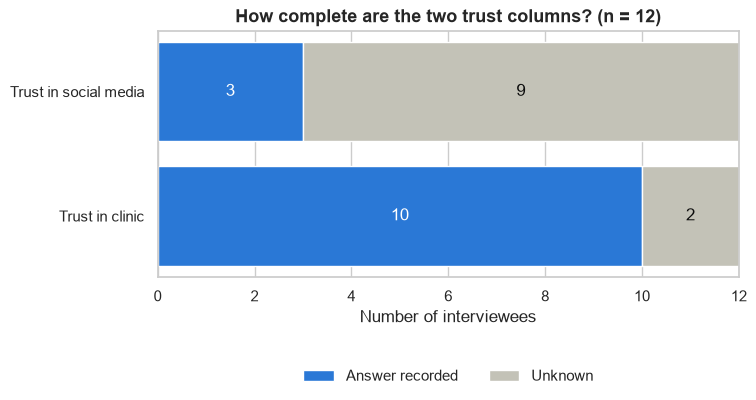

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))                       # one chart, wide and short

# One bar per column, split in two: the known part in blue, the unknown part in grey.
ax.barh(known["column"], known["known"],  color="#2a78d6",      label="Answer recorded")
ax.barh(known["column"], known["unknown"], left=known["known"],
        color="#c3c2b7", label="Unknown")                        # left= starts where the blue bar ends

# Write the number inside each piece of the bar, so the chart can be read without counting.
ax.bar_label(ax.containers[0], label_type="center", color="white")
ax.bar_label(ax.containers[1], label_type="center", color="#0b0b0b")

ax.set_title("How complete are the two trust columns? (n = 12)", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of interviewees")
ax.set_xlim(0, 12)                                               # full width = all 12 girls
# Put the legend under the chart so it never sits on top of a bar or the title.
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.32))
ax.grid(axis="y", visible=False)                                 # no horizontal gridlines on a bar chart

plt.savefig(FIGDIR / "01_completeness.png", dpi=200, bbox_inches="tight")
plt.show()

`trusts_social_media_ord` is unknown for 9 of 12 girls, so we build no finding on it.
The clinic column is usable — 10 of 12 answered — so here is what they said.

In [15]:
# Turn the 0/1/2 scale back into words. .fillna() catches the girls we never asked.
trust = (parts["trusts_clinic_ord"]
         .map({0: "Low trust", 1: "Medium trust", 2: "High trust"})   # numbers -> words
         .fillna("Never asked"))                                      # NaN (was -1)

# reindex() forces a fixed order: low, medium, high, then the unanswered ones last.
order = ["Low trust", "Medium trust", "High trust", "Never asked"]
trust_counts = trust.value_counts().reindex(order, fill_value=0)

trust_counts

trusts_clinic_ord
Low trust       4
Medium trust    5
High trust      1
Never asked     2
Name: count, dtype: int64

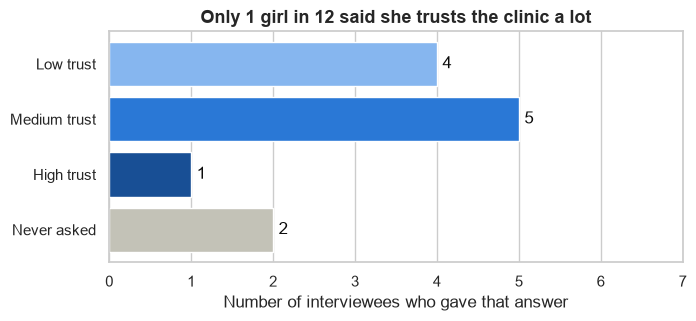

In [16]:
# Light -> dark blue as trust rises, and grey for the girls we never asked.
TRUST_COLORS = ["#86b6ef", "#2a78d6", "#184f95", "#c3c2b7"]

fig, ax = plt.subplots(figsize=(7.4, 3))

# Horizontal, so the bar length reads as "how many girls" and not as "how much trust".
ax.barh(trust_counts.index, trust_counts.values, color=TRUST_COLORS)
ax.invert_yaxis()                                                # Low at the top
ax.bar_label(ax.containers[0], padding=4, color="#0b0b0b")

ax.set_title("Only 1 girl in 12 said she trusts the clinic a lot", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of interviewees who gave that answer")     # spell out what length means
ax.set_xlim(0, 7)
ax.grid(axis="y", visible=False)

plt.savefig(FIGDIR / "02_trust_clinic.png", dpi=200, bbox_inches="tight")
plt.show()

> **Careful with this one: the bar length is the number of girls, not the amount of trust.**
> "High trust" has a short bar because only one girl gave that answer.
>
> Nine of the ten who answered said low or medium. The single girl who said high is P06 — and
> she is also the only girl in section 5 whose first stop is a clinic.

### 2.2 Check the derived column instead of trusting it

`barrier_count` is supposed to be the six barrier flags added up. Let's confirm that
rather than assume it.

In [17]:
# parts[BCOLS] picks out just the six barrier columns; .sum(axis=1) adds each ROW across.
recomputed = parts[BCOLS].sum(axis=1)

# assert stops the notebook loudly if the file and the maths ever disagree.
assert (recomputed == parts["barrier_count"]).all(), "barrier_count does not match the six flags"
print("barrier_count checks out for all 12 rows.")

barrier_count checks out for all 12 rows.


### 2.3 Swap code numbers for words

`first_info_source_code = 5` means nothing on a chart axis. `Online` does.

In [18]:
# .map(SRC) looks each number up in the SRC dictionary and returns the label.
parts["first_source"] = parts["first_info_source_code"].map(SRC)

parts[["participant_id", "neighborhood", "first_source"]].head()

,participant_id,neighborhood,first_source
0,P01,Embakasi,AI
1,P02,Kileleshwa,Family
2,P03,Buruburu,Family
3,P04,Langata,Family
4,P05,Kileleshwa,Family


In [19]:
# Seven of the twelve girls are from Kibera and the other five are one girl each, so
# most comparisons are honest only as "Kibera" vs. "everywhere else in Nairobi".
parts["area"] = np.where(parts["neighborhood"] == "Kibera", "Kibera", "Other Nairobi")

# The two colours we use every time that split appears, so the reader learns them once.
AREA_COLORS = {"Kibera": "#2a78d6", "Other Nairobi": "#eb6834"}

parts["area"].value_counts()

area
Kibera           7
Other Nairobi    5
Name: count, dtype: int64

### 2.4 Give every statement its broad category

In [20]:
# Look each statement's fine theme up in the CATEGORY dictionary.
stmts["category"] = stmts["theme_label"].map(CATEGORY)

# If a theme were missing from the lookup this would be > 0, so check it.
print("statements with no category:", stmts["category"].isna().sum())

stmts["category"].value_counts()

statements with no category: 0


category
structural       16
stigma_social    14
info_source      10
provider          6
Name: count, dtype: int64

### 2.5 The cleaned participant table

This is what every chart below is drawn from.

In [21]:
# Show only the columns we actually use, so the table stays readable.
view = parts[["participant_id", "neighborhood", "area", "age", "in_school",
              "first_source", "barrier_count"]]

# .style colours the table without changing a single number in it: the Kibera rows get a warm
# tint, and barrier_count runs light -> dark, so the girls carrying the most are the darkest.
(view.style
     .apply(lambda row: ["background-color: #fdf0e9" if row["area"] == "Kibera" else ""
                         for _ in row], axis=1)
     .background_gradient(subset=["barrier_count"], cmap="Blues", vmin=0, vmax=6)
     .hide(axis="index"))

participant_id,neighborhood,area,age,in_school,first_source,barrier_count
P01,Embakasi,Other Nairobi,19,1,AI,6
P02,Kileleshwa,Other Nairobi,19,0,Family,3
P03,Buruburu,Other Nairobi,13,1,Family,3
P04,Langata,Other Nairobi,18,1,Family,4
P05,Kileleshwa,Other Nairobi,18,1,Family,4
P06,Kibera,Kibera,19,1,Clinic,3
P07,Kibera,Kibera,19,1,Online,4
P08,Kibera,Kibera,19,1,Online,3
P09,Kibera,Kibera,19,1,Peers,3
P10,Kibera,Kibera,21,0,Peers,4


## 3. Who did we speak to?

Before any finding, the reader needs to know who is in the sample.

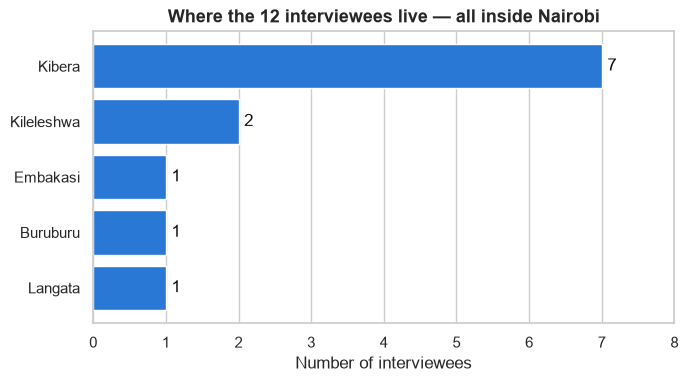

In [22]:
# Count the rows per neighborhood. value_counts() sorts biggest-first for us.
nb_counts = parts["neighborhood"].value_counts()

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.barh(nb_counts.index, nb_counts.values, color="#2a78d6")          # horizontal bars: long names fit
ax.invert_yaxis()                                                # biggest bar at the top
ax.bar_label(ax.containers[0], padding=4, color="#0b0b0b")             # write the number at the end of each bar

ax.set_title("Where the 12 interviewees live — all inside Nairobi", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of interviewees")
ax.set_xlim(0, 8)                                                # leave room for the labels
ax.grid(axis="y", visible=False)

plt.savefig(FIGDIR / "03_neighborhood.png", dpi=200, bbox_inches="tight")
plt.show()

> Kibera is 7 of the 12 — that is where the second round of fieldwork happened. Say it before
> anyone reads a neighborhood comparison in this notebook.

## 4. The barriers

Six barriers, each recorded as a yes/no per girl. Because the column is `1` or `0`,
**adding the column up counts the girls who raised it.**

### What the six labels actually mean

| label | what a `1` in this column means |
|---|---|
| **Stigma** | girls are judged for seeking SRHR services |
| **Low awareness** | girls do not know what exists or how it works |
| **Cost** | money stops her — the service, the clinic card, or the fare |
| **Provider judgment** | a nurse or doctor shamed or dismissed her |
| **Distance / unequal access** | *where you live changes the care you get* |
| **Religious teaching** | a religious rule or teaching stands in the way |

**"Distance / unequal access" is not about living in the countryside** — every girl here lives
in Nairobi. The quotes below show what the two easily-misread labels actually cover.

In [23]:
# Pull the quotes whose theme is about religion, and the ones about distance or unequal access.
faith    = stmts[stmts["theme_label"].isin(["religion", "beliefs_traditional"])]
distance = stmts[stmts["theme_label"].isin(["distance_rural", "distance_inequality"])]

print("QUOTES BEHIND 'Religious teaching'")
for t in faith["statement_text"]:
    print("  -", t)

print()
print("QUOTES BEHIND 'Distance / unequal access'")
for t in distance["statement_text"]:
    print("  -", t)

QUOTES BEHIND 'Religious teaching'
  - Islam access restricted by gender of the provider
  - Beliefs that women give birth at home with witch doctors instil fear
  - Religious teaching discourages contraception

QUOTES BEHIND 'Distance / unequal access'
  - Kibera girls dismissed; Muthaiga girls get fast good care
  - In rural areas the services are inaccessible
  - Girls in Westlands pay private hospitals; here poverty exposes you
  - Pastoralist and some Muslim communities face compounded barriers


> Faith is in the transcripts, and one quote names Islam. The distance quotes split two ways:
> two are Nairobi-against-Nairobi (Kibera vs Muthaiga, Westlands private hospitals), two are
> girls describing women elsewhere. That mix is why "Distance/rural" was the wrong name.

In [24]:
# Build the table first, then plot it - always in that order, so the numbers can be checked.
barrier_freq = pd.DataFrame({
    "barrier": BNAME,                                   # the readable names
    "count":   [int(parts[c].sum()) for c in BCOLS],    # summing a 0/1 column = counting the 1s
}).sort_values("count", ascending=False)                # biggest first

barrier_freq

,barrier,count
0,Stigma,12
1,Low awareness,8
2,Cost,7
3,Provider judgment,6
4,Distance / unequal access,4
5,Religious teaching,4


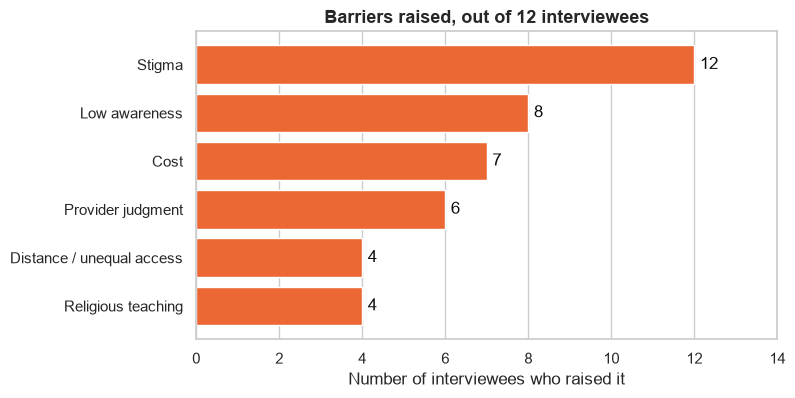

In [25]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.barh(barrier_freq["barrier"], barrier_freq["count"], color="#eb6834")
ax.invert_yaxis()
ax.bar_label(ax.containers[0], padding=4, color="#0b0b0b")

ax.set_title("Barriers raised, out of 12 interviewees", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of interviewees who raised it")
ax.set_xlim(0, 14)
ax.grid(axis="y", visible=False)

plt.savefig(FIGDIR / "04_barriers.png", dpi=200, bbox_inches="tight")
plt.show()

> **Stigma is 12 out of 12** — the only unanimous answer. Low awareness (8) and cost (7) next.

### How many barriers is one girl carrying?

The chart above counts barriers. This one counts *girls* — because a girl facing four
barriers at once is a different problem from four girls facing one each.

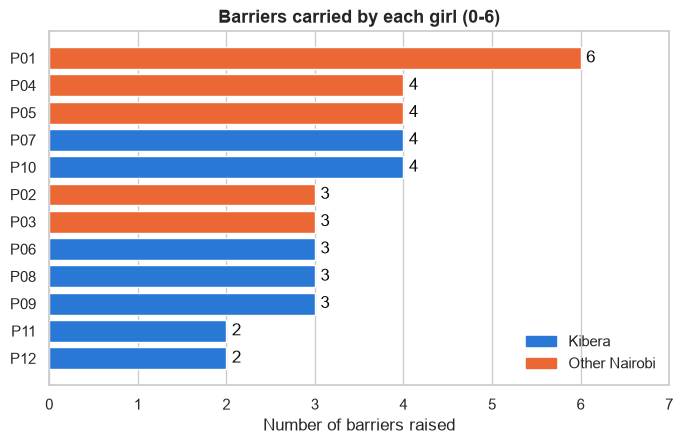

In [26]:
# Sort the girls by how many barriers they raised, so the chart reads as a ranking.
load = parts.sort_values("barrier_count", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.6))

# One bar per girl, coloured by area, so the Kibera rows are visible inside the ranking.
ax.barh(load["participant_id"], load["barrier_count"],
        color=[AREA_COLORS[a] for a in load["area"]])            # look each girl's colour up
ax.invert_yaxis()
ax.bar_label(ax.containers[0], padding=4, color="#0b0b0b")

# Build the legend by hand, because we coloured the bars ourselves.
from matplotlib.patches import Patch                             # Patch = a coloured square for a legend
ax.legend(handles=[Patch(color=c, label=a) for a, c in AREA_COLORS.items()],
          frameon=False, loc="lower right")

ax.set_title("Barriers carried by each girl (0-6)", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of barriers raised")
ax.set_xlim(0, 7)
ax.grid(axis="y", visible=False)

plt.savefig(FIGDIR / "05_barrier_load.png", dpi=200, bbox_inches="tight")
plt.show()

### The same 12 girls, showing *which* barriers

One column per girl, one row per barrier, a filled square means she raised it.

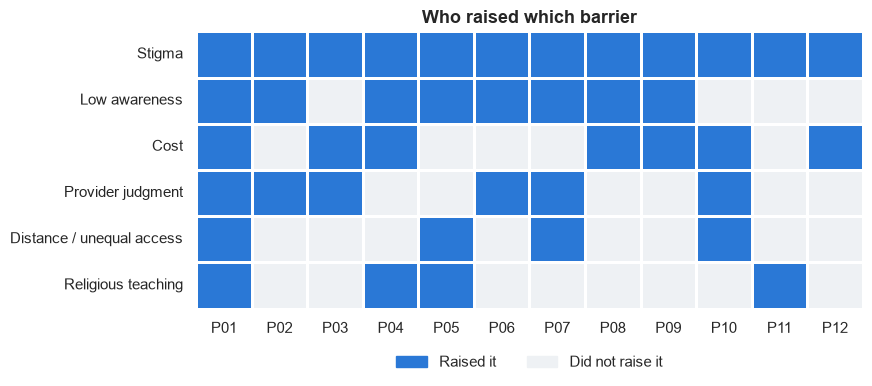

In [27]:
from matplotlib.colors import ListedColormap                     # a colour map of exactly 2 colours
from matplotlib.patches import Patch                             # coloured squares for the legend

# parts[BCOLS].T flips the table: rows become the 6 barriers, columns become the 12 girls.
grid = parts[BCOLS].T
grid.index   = BNAME                                             # readable barrier names down the side
grid.columns = parts["participant_id"]                           # P01...P12 along the bottom

fig, ax = plt.subplots(figsize=(8.6, 3.6))

# 0 -> pale grey (did not raise it), 1 -> blue (raised it).
sns.heatmap(grid, cmap=ListedColormap(["#eef1f4", "#2a78d6"]), cbar=False,
            linewidths=2, linecolor="white", ax=ax)

ax.set_title("Who raised which barrier", fontsize=13, fontweight="bold")
ax.set_xlabel(""); ax.set_ylabel("")
plt.yticks(rotation=0); plt.xticks(rotation=0)

# The colours mean something, so say what - two squares under the chart.
ax.legend(handles=[Patch(color="#2a78d6", label="Raised it"),
                   Patch(color="#eef1f4", label="Did not raise it")],
          frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12))

plt.savefig(FIGDIR / "06_who_raised_what.png", dpi=200, bbox_inches="tight")
plt.show()

> The top row is solid: stigma, all 12. Read *down* any column and no girl has only one
> square — the thinnest still has two.

### Which barriers turn up in which neighborhood?

One row per neighborhood, one column per barrier; the number is how many girls *from that
neighborhood* raised it.

**Where the numbers look like they disagree, they do not.** Religious teaching is `4` in the
bar chart and `1` in four rows here — the same four girls, one per neighborhood. Add a column
here and you get the bar chart's total back.

In [28]:
# groupby("neighborhood") makes one group per neighborhood; .sum() adds the 0/1 flags inside it.
by_nb = parts.groupby("neighborhood")[BCOLS].sum()

# Swap the technical column names for the readable ones.
by_nb.columns = BNAME

# Put the number of girls into the row label, so nobody compares a row of 7 with a row of 1.
sizes = parts["neighborhood"].value_counts()
by_nb.index = [f"{nb}  (n={sizes[nb]})" for nb in by_nb.index]

by_nb

,Stigma,Low awareness,Cost,Provider judgment,Distance / unequal access,Religious teaching
Buruburu (n=1),1,0,1,1,0,0
Embakasi (n=1),1,1,1,1,1,1
Kibera (n=7),7,4,4,3,2,1
Kileleshwa (n=2),2,2,0,1,1,1
Langata (n=1),1,1,1,0,0,1


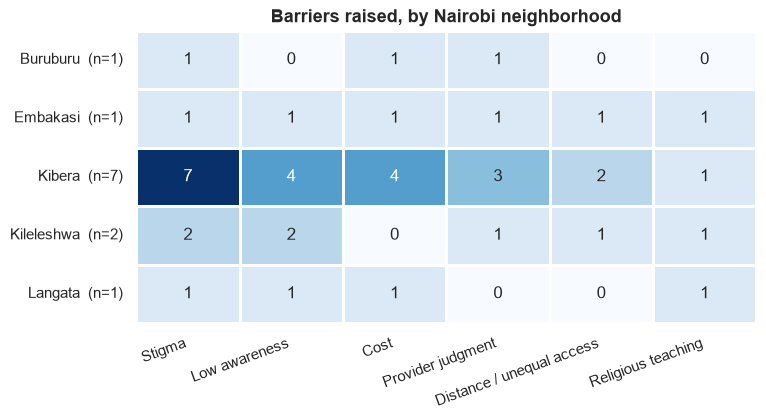

In [29]:
fig, ax = plt.subplots(figsize=(8, 3.8))

# annot=True writes the count inside each square; fmt="d" keeps them whole numbers.
sns.heatmap(by_nb, annot=True, fmt="d", cmap="Blues", cbar=False,
            linewidths=2, linecolor="white", ax=ax)              # white lines = a gap between squares

ax.set_title("Barriers raised, by Nairobi neighborhood", fontsize=13, fontweight="bold")
ax.set_xlabel(""); ax.set_ylabel("")
plt.xticks(rotation=20, ha="right")

plt.savefig(FIGDIR / "07_barrier_by_neighborhood.png", dpi=200, bbox_inches="tight")
plt.show()

In [30]:
# Name the girls behind the two barriers that raise the most questions, so a number
# on a chart can always be traced back to a person and a neighborhood.
for col, label in [("barrier_religion", "Religious teaching"),
                   ("barrier_distance_rural", "Distance / unequal access")]:
    who = parts.loc[parts[col] == 1, ["participant_id", "neighborhood"]]     # rows flagged 1
    print(f"{label}: {len(who)} girls")
    print(who.to_string(index=False))
    print()

Religious teaching: 4 girls
participant_id neighborhood
           P01     Embakasi
           P04      Langata
           P05   Kileleshwa
           P11       Kibera

Distance / unequal access: 4 girls
participant_id neighborhood
           P01     Embakasi
           P05   Kileleshwa
           P07       Kibera
           P10       Kibera



### Which barriers land on the same girl?

Same idea, but barrier against barrier. The square where *Cost* meets *Stigma* is the number
of girls who raised **both**. The diagonal is just the total for that barrier.

In [31]:
# B is a 12 x 6 grid of 0s and 1s. B.T @ B is matrix multiplication: the square at (i, j)
# ends up being the number of girls with a 1 in BOTH column i and column j.
B = parts[BCOLS].to_numpy()
co = pd.DataFrame(B.T @ B, index=BNAME, columns=BNAME)

co

,Stigma,Low awareness,Cost,Provider judgment,Distance / unequal access,Religious teaching
Stigma,12,8,7,6,4,4
Low awareness,8,8,4,4,3,3
Cost,7,4,7,3,2,2
Provider judgment,6,4,3,6,3,1
Distance / unequal access,4,3,2,3,4,2
Religious teaching,4,3,2,1,2,4


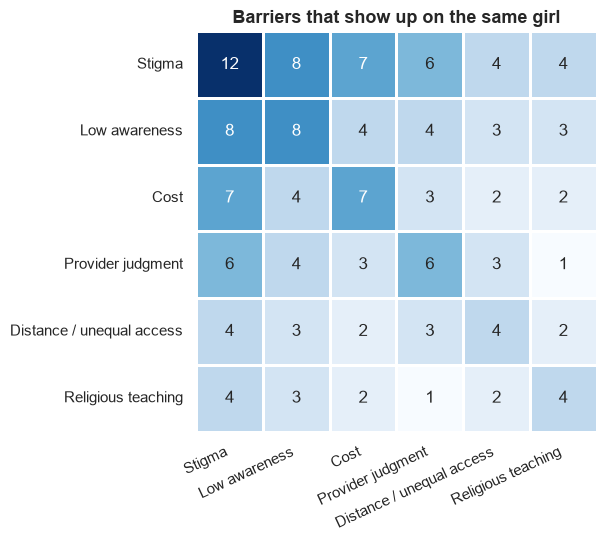

In [32]:
fig, ax = plt.subplots(figsize=(6.6, 5.2))
sns.heatmap(co, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
            linewidths=2, linecolor="white", ax=ax)

ax.set_title("Barriers that show up on the same girl", fontsize=13, fontweight="bold")
ax.set_xlabel(""); ax.set_ylabel("")
plt.xticks(rotation=25, ha="right"); plt.yticks(rotation=0)

plt.savefig(FIGDIR / "08_cooccurrence.png", dpi=200, bbox_inches="tight")
plt.show()

> Every girl who raised cost, religious teaching, unequal access or provider judgment **also**
> raised stigma. Barriers do not arrive one at a time.

### What else did the 12 tell us?

Six more yes/no answers were recorded for every girl, and none of them appear in a chart above.
They are not barriers, so they do not belong in section 4's counts — but they are answers we
collected, and leaving them unread in the file is throwing data away.

In [33]:
# Six yes/no columns no chart above has used. Summing a 0/1 column counts the girls who said yes.
EXTRA = {
    "in_school":                         "Still in school",
    "service_stigma_aware":              "Knows stigma differs by service",
    "privacy_secrecy_concern":           "Raised privacy or secrecy",
    "digital_first_source":              "Goes to a screen first",
    "wants_comprehensive_sex_ed":        "Asked for comprehensive sex ed",
    "personally_experienced_difficulty": "Describes a difficulty as her own",
}

extra_freq = pd.DataFrame({
    "answer": list(EXTRA.values()),
    "count":  [int(parts[c].sum()) for c in EXTRA],
}).sort_values("count", ascending=False)

extra_freq

,answer,count
0,Still in school,10
1,Knows stigma differs by service,7
2,Raised privacy or secrecy,5
3,Goes to a screen first,4
4,Asked for comprehensive sex ed,3
5,Describes a difficulty as her own,2


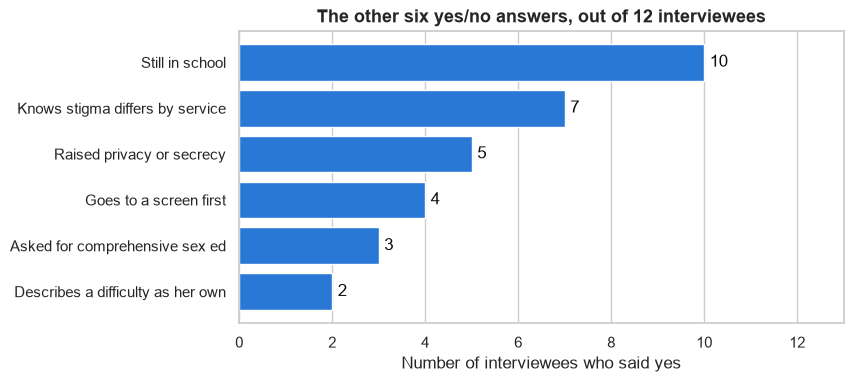

In [34]:
fig, ax = plt.subplots(figsize=(7.8, 3.8))
ax.barh(extra_freq["answer"], extra_freq["count"], color="#2a78d6")
ax.invert_yaxis()
ax.bar_label(ax.containers[0], padding=4, color="#0b0b0b")

ax.set_title("The other six yes/no answers, out of 12 interviewees", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of interviewees who said yes")
ax.set_xlim(0, 13)
ax.grid(axis="y", visible=False)

plt.savefig(FIGDIR / "09_what_else.png", dpi=200, bbox_inches="tight")
plt.show()

> **Only 3 of 12 asked for comprehensive sex ed**, against 12 of 12 who raised stigma. The girls
> name the judgment; they do not, unprompted, name the fix. Two describe a difficulty as their
> own rather than as something that happens to girls in general — that low number is about how
> they speak in an interview, not about how much they have been through.

## 5. Where do girls go for information?

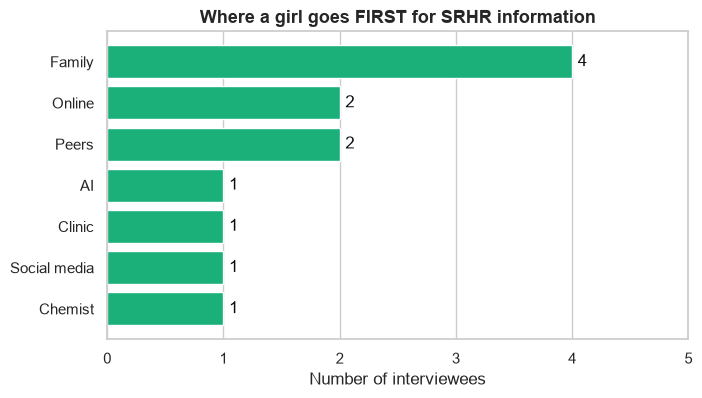

In [35]:
# Count the girls per first source, most common first.
first_counts = parts["first_source"].value_counts()

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.barh(first_counts.index, first_counts.values, color="#1baf7a")
ax.invert_yaxis()
ax.bar_label(ax.containers[0], padding=4, color="#0b0b0b")             # labels also make the light bar readable

ax.set_title("Where a girl goes FIRST for SRHR information", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of interviewees")
ax.set_xlim(0, 5)
ax.grid(axis="y", visible=False)

plt.savefig(FIGDIR / "10_first_source.png", dpi=200, bbox_inches="tight")
plt.show()

> The clinic is **one** girl's first stop. Girls route around the place we expect them to go.

### The same answers, in three buckets

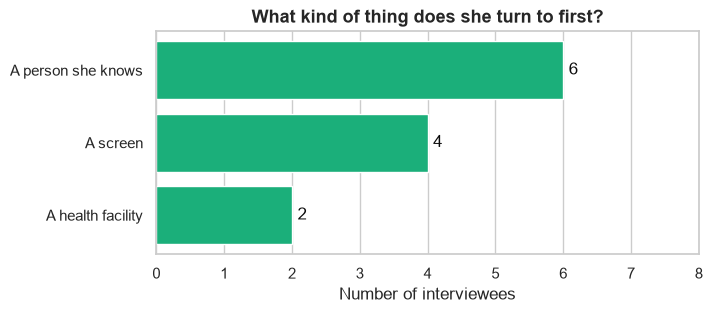

In [36]:
# Sort the seven sources into three kinds of first stop.
KIND = {"Family": "A person she knows", "Peers": "A person she knows",
        "AI": "A screen", "Online": "A screen", "Social media": "A screen",
        "Clinic": "A health facility", "Chemist": "A health facility"}

# .map() applies that grouping, then value_counts() counts each bucket.
kind_counts = (parts["first_source"].map(KIND).value_counts()
               .reindex(["A person she knows", "A screen", "A health facility"]))

fig, ax = plt.subplots(figsize=(7, 2.9))
ax.barh(kind_counts.index, kind_counts.values, color="#1baf7a")
ax.invert_yaxis()
ax.bar_label(ax.containers[0], padding=4, color="#0b0b0b")

ax.set_title("What kind of thing does she turn to first?", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of interviewees")
ax.set_xlim(0, 8)
ax.grid(axis="y", visible=False)

plt.savefig(FIGDIR / "11_first_stop_type.png", dpi=200, bbox_inches="tight")
plt.show()

> **Ten of twelve go to a person or a screen first.** P07 said why: *"it will not judge me."*

### Is her first stop also the one she trusts most?

Two separate columns were coded from two separate questions: where she goes first, and which
source she trusts most. Check them against each other rather than assuming they agree.

In [37]:
# Compare the two columns row by row instead of trusting that they say different things.
same = parts["first_info_source_code"] == parts["main_trusted_source_code"]

print("first stop IS her most-trusted source:", int(same.sum()), "of", len(parts), "girls")
print("goes somewhere she trusts less:      ", int((~same).sum()))

first stop IS her most-trusted source: 12 of 12 girls
goes somewhere she trusts less:       0


> **All 12.** No girl in this sample goes somewhere she doubts. Read against the chart above,
> that changes what the clinic number means: it is not that she cannot reach the clinic and
> settles for a friend — the friend *is* the source she believes.
>
> The flat 12 of 12 is also a flag for whoever codes the next batch. If the guide asks both
> questions, the answers should be free to differ, and here they never once do. Worth confirming
> the two were coded independently before this is reported as a finding.

## 6. Does age explain anything?

One scatter plot. With **n = 12** it is for *spotting a shape worth asking about*, never for
proving one.

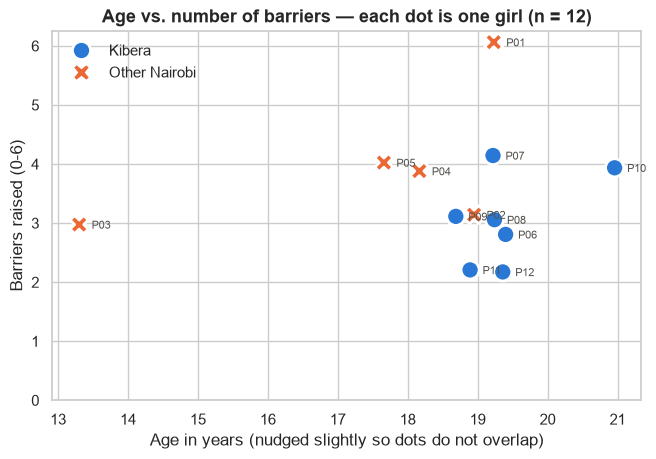

In [38]:
# Age and barrier_count are both whole numbers, so several girls land on the exact same
# spot and you would see one dot instead of three. A tiny random nudge (jitter) fixes that.
rng = np.random.default_rng(42)                                  # fixed seed -> the same nudge every run
p = parts.copy()                                                 # work on a copy, never the clean table
p["age_j"] = p["age"]           + rng.uniform(-0.42, 0.42, len(p))
p["bar_j"] = p["barrier_count"] + rng.uniform(-0.22, 0.22, len(p))

fig, ax = plt.subplots(figsize=(7.6, 4.8))

# hue = colour by area; style = a different marker shape, so the two groups differ twice over.
sns.scatterplot(data=p, x="age_j", y="bar_j", hue="area", style="area",
                hue_order=["Kibera", "Other Nairobi"], style_order=["Kibera", "Other Nairobi"],
                palette=AREA_COLORS, s=170, edgecolor="white", linewidth=2, ax=ax)

# Write each girl's ID next to her dot, so a point can be traced back to a transcript.
for _, r in p.iterrows():
    ax.annotate(r["participant_id"], (r["age_j"], r["bar_j"]),
                xytext=(9, -3), textcoords="offset points", fontsize=8, color="#52514e")

ax.set_title("Age vs. number of barriers — each dot is one girl (n = 12)", fontsize=13, fontweight="bold")
ax.set_xlabel("Age in years (nudged slightly so dots do not overlap)")
ax.set_ylabel("Barriers raised (0-6)")
ax.set_yticks(range(0, 7))                                       # whole numbers only - you cannot raise 3.5 barriers
ax.legend(frameon=False, title="")

plt.savefig(FIGDIR / "12_scatter_age_barriers.png", dpi=200, bbox_inches="tight")
plt.show()

> No age trend: the 13-year-old and the 21-year-old carry the same load.

## 7. What the 46 statements say

Back to the quotes. Each is tagged with a fine theme, and those themes group into
4 broad categories.

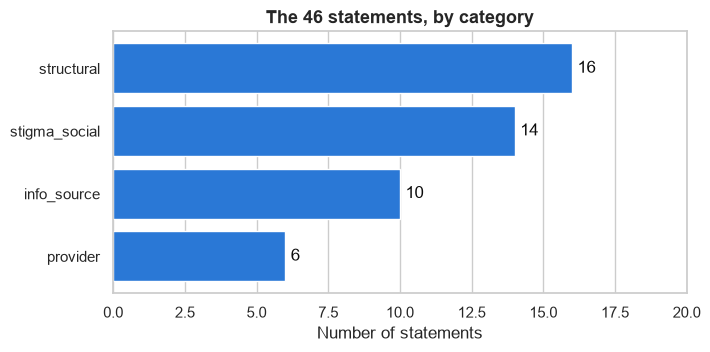

In [39]:
# Count the statements per broad category.
cat_counts = stmts["category"].value_counts()

fig, ax = plt.subplots(figsize=(7.4, 3.4))
ax.barh(cat_counts.index, cat_counts.values, color="#2a78d6")
ax.invert_yaxis()
ax.bar_label(ax.containers[0], padding=4, color="#0b0b0b")

ax.set_title("The 46 statements, by category", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of statements")
ax.set_xlim(0, 20)
ax.grid(axis="y", visible=False)

plt.savefig(FIGDIR / "13_categories.png", dpi=200, bbox_inches="tight")
plt.show()

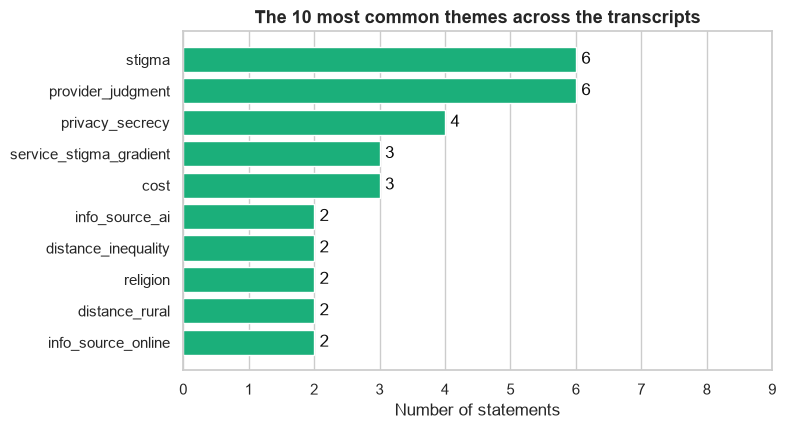

In [40]:
# The 10 most common fine themes, so the categories above can be unpacked.
top_themes = stmts["theme_label"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.barh(top_themes.index, top_themes.values, color="#1baf7a")
ax.invert_yaxis()
ax.bar_label(ax.containers[0], padding=4, color="#0b0b0b")

ax.set_title("The 10 most common themes across the transcripts", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of statements")
ax.set_xlim(0, 9)
ax.grid(axis="y", visible=False)

plt.savefig(FIGDIR / "14_top_themes.png", dpi=200, bbox_inches="tight")
plt.show()

### Why we are not putting a model on this yet

A text model learns by seeing **the same word again and again** across examples. So: how often
does a word actually repeat across the 46 statements?

In [41]:
# Take all 46 statements, lowercase them, and split each one into words.
words = stmts["statement_text"].str.lower().str.split()

# .explode() turns a list of words in one row into one word per row.
# .value_counts() then counts how many times each distinct word appears in the whole set.
word_freq = words.explode().value_counts()

print("distinct words across all 46 statements:", len(word_freq))
word_freq.head(8)

distinct words across all 46 statements: 275


statement_text
and      13
a        11
the      11
you      10
girls     7
of        7
for       7
are       6
Name: count, dtype: int64

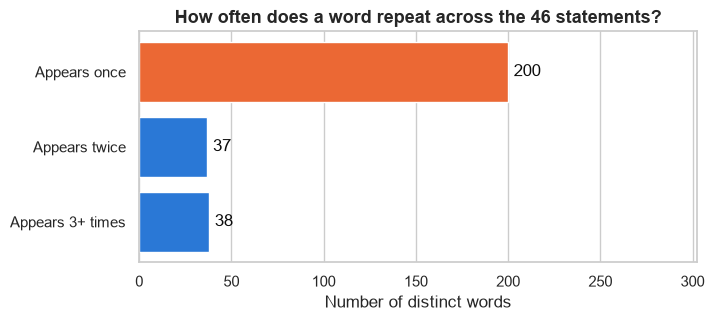

In [42]:
# Sort those distinct words into three buckets by how many times they appeared.
buckets = pd.Series({
    "Appears once":        int((word_freq == 1).sum()),
    "Appears twice":       int((word_freq == 2).sum()),
    "Appears 3+ times":    int((word_freq >= 3).sum()),
})

fig, ax = plt.subplots(figsize=(7.2, 3))
ax.barh(buckets.index, buckets.values, color=["#eb6834", "#2a78d6", "#2a78d6"])
ax.invert_yaxis()
ax.bar_label(ax.containers[0], padding=4, color="#0b0b0b")

ax.set_title("How often does a word repeat across the 46 statements?", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of distinct words")
ax.set_xlim(0, len(word_freq) * 1.1)
ax.grid(axis="y", visible=False)

plt.savefig(FIGDIR / "15_word_repetition.png", dpi=200, bbox_inches="tight")
plt.show()

> Most of the vocabulary appears **exactly once**, and the words that do repeat are `and`,
> `a`, `the`, `you` — only the meaningless ones are common. A model would be reading sentences
> made of words it has never met. **More transcripts fix that; a fancier model does not.**

## 8. What the charts show

These come from the charts above, and they hold up.

1. **Stigma is universal in this sample.** 12 of 12 — the only unanimous answer in the whole
   dataset.
2. **After stigma come low awareness (8 of 12) and cost (7 of 12).**
3. **Barriers stack.** The co-occurrence grid shows every girl who named cost, religious
   teaching, unequal access or provider judgment also named stigma.
4. **Where you live changes the care you get — inside one city.** Four girls said so directly:
   Kibera dismissed, Muthaiga seen quickly, Westlands able to pay private.
5. **Girls route around judgment.** The clinic is the first stop for exactly one girl.
   Family, peers and the internet come first for everyone else.
6. **She goes where she trusts.** First stop and most-trusted source are the same answer for
   all 12 girls, so the routing around the clinic is a belief about the clinic, not a problem
   of getting to one.
7. **Age explains nothing.** The 13-year-old and the 21-year-old carry the same barrier load.
8. **Kibera is 7 of the 12 interviews.** Every neighborhood comparison in this notebook is a
   description of who we spoke to, not a claim about the neighborhoods.

## 9. What this does not show

- 12 interviews and 1 focus group. **Qualitative research, not a survey.** Nothing here
  generalises to Nairobi as a whole.
- The sample is Kibera 7, Kileleshwa 2, and **one girl each** for Buruburu, Embakasi and
  Langata. A single row is a story, not a rate.
- We assigned the theme of every quote ourselves while reading the transcripts. A different
  pair of readers would code some of them differently.
- `trusts_social_media_ord` is unknown for 9 of 12 girls, and `uses_ai` is true for 1.
  **We build nothing on either.**
- `first_info_source_code` and `main_trusted_source_code` are identical in all 12 rows. We report
  it as a finding, but it would also be the signature of the two questions having been coded from
  one answer. **Confirm they were coded independently before quoting finding 6.**

## 10. What we would do next

### On the dataset

1. **Code more transcripts — this is the one that unlocks everything else.** Every table is
   read from a CSV, so adding rows to `data/participants.csv` or `data/statements.csv` and
   pressing Run All is the whole job. No code changes.
2. **Widen the neighborhoods.** 7 of 12 girls are from Kibera. Interviews in the estates we
   have only one girl from — Buruburu, Embakasi, Langata — would turn every "n=1" row in the
   neighborhood heatmap into something we can actually compare.
3. **Fill in the trust questions.** `trusts_social_media_ord` is unknown for 9 of 12 girls
   because it was never asked consistently. Putting it in the interview guide costs nothing
   and would give us a real column instead of a blank one.
4. **Split "Distance / unequal access" into two columns.** The quotes showed it is doing two
   jobs at once — unequal care between Nairobi addresses, and services being far away. Two
   separate flags would be cleaner than one label that needs a paragraph of explanation.
5. **Have a second person code the statements.** Right now one reader assigned every theme.
   Two readers coding the same transcripts, and measuring where they disagree, is what turns
   our coding from a judgment call into a method.

### On the machine-learning part

1. **The blocker is measured, not guessed** — section 7 shows 200 of 275 distinct words appear
   exactly once. Roughly 150–200 coded statements is where a text classifier starts having
   repeated vocabulary to learn from. That is the number to aim at.
2. **Set the baseline before the model.** A `DummyClassifier` that always answers the biggest
   category scores about 35% here. Any model we build has to beat that number honestly, on a
   test set it has never seen, or it is not worth reporting.
3. **Then TF-IDF + a RandomForest**, tuned with `GridSearchCV` on the training split only, and
   scored once at the end on the held-out test set.
4. **Report it straight, including a bad result.** A model that barely beats the baseline is a
   finding about the size of the dataset, not a failure of the code — and a model scoring
   suspiciously well on 46 sentences would be leaking, not learning.
5. **Predicting the barrier, not the category, is the more useful goal** if the dataset ever
   gets big enough: reading a girl's concern and flagging *which barrier she is facing* is
   what would actually route her to the right kind of help.